In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report,confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

import tensorflow as tf 
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


2026-03-15 07:05:27.640022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773558328.122830      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773558328.306866      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773558329.523014      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773558329.523060      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773558329.523062      23 computation_placer.cc:177] computation placer alr

In [2]:
train_df = pd.read_csv("/kaggle/input/competitions/nlp-getting-started/train.csv")
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## Data Processing

First I will try to see the information about the dataset

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


From the information, it seems that there are only 2 columns that are valueable for the training. Thus I will drop other columns.

In [4]:
train_df['text_combined'] = train_df['keyword'].fillna('') + " " + \
                             train_df['location'].fillna('') + " " + \
                             train_df['text']

In [5]:
import re

def light_clean(text):
    # 1. Replace URLs with 'url'
    text = re.sub(r'https?://\S+|www\.\S+', 'url', text)
    # 2. Replace @mentions with 'user'
    text = re.sub(r'@\S+', 'user', text)
    # 3. Fix the "heat...wave" issue by replacing multiple dots with a space
    text = re.sub(r'\.\.\.', ' ', text)
    # 4. Remove weird HTML characters like &amp; or ‰ÛÏ
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'[^\x00-\x7f]', r'', text) # Remove non-ascii characters
    return text

# Apply this to your 'text_combined' (the one with keywords)
train_df['text_cleaned'] = train_df['text_combined'].apply(light_clean)

In [6]:
train_df.drop(columns=["id", "keyword", "location"], inplace=True)

Since I have cleaned the data, now it's time to split it for training

In [7]:
X = train_df["text_cleaned"]
y = train_df["target"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

Next I will see the word count of the each tweet, this will be useful for the tokenization

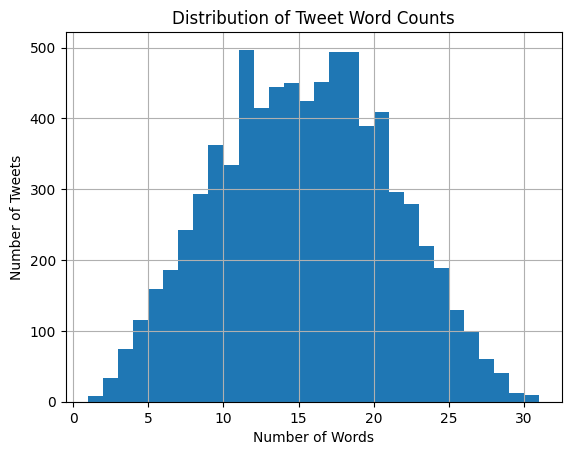

In [8]:
train_df['text'].apply(lambda x: len(str(x).split())).hist(bins=30)
plt.title('Distribution of Tweet Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Number of Tweets')
plt.show()

From the graph, the max number of words is about 32. So next I will tokenize the word.

In [9]:
# 1. Initialize the "Dictionary" (Limit to the top 10,000 words)
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train) # Learn words from training data only!

# 2. Convert words to numbers
train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)

# 3. Make every tweet exactly 35 numbers long
# We pad with zeros at the end ('post')
max_length = 35
X_train_ready = pad_sequences(train_sequences, maxlen=max_length, padding='pre', truncating='post')
X_val_ready = pad_sequences(val_sequences, maxlen=max_length, padding='pre', truncating='post')

## Baseline Model
This will be the model train with CNN

In [10]:
model = tf.keras.Sequential([
    layers.Embedding(10000, 16),
    layers.SpatialDropout1D(0.2), # Prevent word-feature memorization
    layers.Bidirectional(layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.4), # Final shield against overfitting
    layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

I0000 00:00:1773558366.917291      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773558366.920269      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(X_train_ready, y_train, epochs=10, validation_data=(X_val_ready, y_val), callbacks=[early_stop])

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.5891 - loss: 0.6689 - val_accuracy: 0.7741 - val_loss: 0.4933
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.8314 - loss: 0.4260 - val_accuracy: 0.8083 - val_loss: 0.4424
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.8873 - loss: 0.3070 - val_accuracy: 0.7866 - val_loss: 0.4887
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.9052 - loss: 0.2581 - val_accuracy: 0.7787 - val_loss: 0.5254


In [12]:
# 1. Get probabilities
y_pred_probs = model.predict(X_val_ready)

# 2. Convert probabilities to binary (0 or 1) using a threshold
y_pred = (y_pred_probs > 0.3).astype("int32")

# 3. Calculate F1
f1 = f1_score(y_val, y_pred)
print(f"F1 Score: {f1:.4f}")
print(classification_report(y_val, y_pred, target_names=['Not Disaster', 'Disaster']))

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
F1 Score: 0.7539
              precision    recall  f1-score   support

Not Disaster       0.83      0.78      0.80       869
    Disaster       0.73      0.78      0.75       654

    accuracy                           0.78      1523
   macro avg       0.78      0.78      0.78      1523
weighted avg       0.78      0.78      0.78      1523



In [13]:
# Find indices where it was a Disaster (1) but we predicted Not Disaster (0)
false_negatives = (y_val == 1) & (y_pred.flatten() == 0)

# Show the first 5 missed disasters
missed_tweets = X_val[false_negatives].iloc[:5]
for tweet in missed_tweets:
    print(f"MISSING DISASTER: {tweet}\n")

MISSING DISASTER: cliff%20fall nyc ok peace I hope I fall off a cliff along with my dignity

MISSING DISASTER: tornado Asheville, NC I liked a user video url Lexi Belle for Oklahoma tornado victims

MISSING DISASTER: windstorm Webster, TX TWIA board approves 5 percent rate hike: The Texas Windstorm Insurance Association (TWIA) Board of Directors v  url

MISSING DISASTER: upheaval  How long O Lord (Study 3)
 The sixth seal opens the events of Revelation 12. The political upheaval in the Roman  url

MISSING DISASTER: sunk New York Aquarium Ornament Wreck Sailing Boat Sunk Ship Destroyer Fish Tank Cave Decor - Full read _ url url



## Improve the model
Now since I already have the baseline model, I will try to improve it. From the missing disaster, I think that the vocabulary of the model is not enough. So I will use the **GloVe** a pre-trained dictionary.

In [14]:
glove_path = '/kaggle/input/datasets/yesornope/glove6b/glove.6B.100d.txt'
embeddings_index = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 400001 word vectors.


In [15]:
embedding_dim = 100 # Match the GloVe file dimension
word_index = tokenizer.word_index
num_words = min(10000, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    if i < 10000:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

In [16]:
model_v2 = tf.keras.Sequential([
    layers.Embedding(num_words, 
                     embedding_dim, 
                     embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
                     trainable=False), # Freeze the "dictionary" first
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.GlobalMaxPool1D(), # Picks out the most "intense" signals from the LSTM
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model_v2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [17]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_v2.fit(X_train_ready, y_train, epochs=10, validation_data=(X_val_ready, y_val), callbacks=[early_stop])

Epoch 1/10


I0000 00:00:1773558510.724053      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6999 - loss: 0.5769 - val_accuracy: 0.7997 - val_loss: 0.4548
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7683 - loss: 0.4783 - val_accuracy: 0.7912 - val_loss: 0.4559
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8022 - loss: 0.4475 - val_accuracy: 0.8076 - val_loss: 0.4313
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8166 - loss: 0.4189 - val_accuracy: 0.7965 - val_loss: 0.4474
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8166 - loss: 0.4141 - val_accuracy: 0.8129 - val_loss: 0.4201
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8330 - loss: 0.3871 - val_accuracy: 0.8155 - val_loss: 0.4186
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8336 - loss: 0.3870 - val_accuracy: 0.8168 - val_loss: 0.4173
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8393 - loss: 0.3703 - val_accuracy: 0.8063 - val

In [18]:
model_v2.layers[0].trainable = True
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_finetune = model_v2.fit(
    X_train_ready, 
    y_train,
    epochs=5, 
    validation_data=(X_val_ready, y_val),
    callbacks=[early_stop]
)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8508 - loss: 0.3551 - val_accuracy: 0.8155 - val_loss: 0.4157
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8465 - loss: 0.3631 - val_accuracy: 0.8148 - val_loss: 0.4160
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8509 - loss: 0.3502 - val_accuracy: 0.8142 - val_loss: 0.4164
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8433 - loss: 0.3584 - val_accuracy: 0.8142 - val_loss: 0.4166


In [19]:
y_pred_probs = model_v2.predict(X_val_ready)

y_pred = (y_pred_probs > 0.34).astype("int32")

# 3. Calculate F1
f1 = f1_score(y_val, y_pred)
print(f"F1 Score: {f1:.4f}")
print(classification_report(y_val, y_pred, target_names=['Not Disaster', 'Disaster']))

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
F1 Score: 0.7710
              precision    recall  f1-score   support

Not Disaster       0.83      0.81      0.82       869
    Disaster       0.76      0.79      0.77       654

    accuracy                           0.80      1523
   macro avg       0.79      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523



In [20]:
# 1. Get the raw probabilities from fine-tuned model
y_probs = model_v2.predict(X_val_ready)

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

# 2. Test each threshold
for t in thresholds:
    y_pred = (y_probs > t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred))

# 3. Find the winner
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Optimal Threshold: 0.39
Best F1 Score: 0.7811


## DistilBert

In [21]:
!pip install -q transformers datasets

In [22]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import Dataset

In [23]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=64)

train_ds = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train}))
val_ds = Dataset.from_pandas(pd.DataFrame({'text': X_val, 'label': y_val}))

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

In [24]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

 Using device: cuda


In [25]:
from transformers import logging
logging.set_verbosity_error()
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.parallel._functions")

In [26]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Load the Pre-trained Model with 2 labels (Disaster or Not)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model = model.to(device)

# 2. Define the Evaluation Metric (F1 Score)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"f1": f1_score(labels, predictions)}

# 3. Set Training Parameters
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=1e-5,
    per_device_train_batch_size=16,

    logging_steps=100,   
    
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# 4. The Trainer (The "Hyperbolic Time Chamber")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '1.079', 'grad_norm': '11.84', 'learning_rate': '8.963e-06', 'epoch': '0.5236'}
{'eval_loss': '0.8078', 'eval_f1': '0.7906', 'eval_runtime': '3.537', 'eval_samples_per_second': '430.6', 'eval_steps_per_second': '27.14', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.8373', 'grad_norm': '8.915', 'learning_rate': '7.916e-06', 'epoch': '1.047'}
{'loss': '0.7316', 'grad_norm': '16.18', 'learning_rate': '6.869e-06', 'epoch': '1.571'}
{'eval_loss': '0.7722', 'eval_f1': '0.8041', 'eval_runtime': '3.581', 'eval_samples_per_second': '425.3', 'eval_steps_per_second': '26.81', 'epoch': '2'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.5694', 'grad_norm': '6.332', 'learning_rate': '1.634e-06', 'epoch': '4.188'}
{'loss': '0.5591', 'grad_norm': '10.6', 'learning_rate': '5.864e-07', 'epoch': '4.712'}
{'eval_loss': '0.7918', 'eval_f1': '0.8124', 'eval_runtime': '3.6', 'eval_samples_per_second': '423.1', 'eval_steps_per_second': '26.67', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '159.3', 'train_samples_per_second': '191.1', 'train_steps_per_second': '5.994', 'train_loss': '0.7132', 'epoch': '5'}


TrainOutput(global_step=955, training_loss=0.7131831263996544, metrics={'train_runtime': 159.3167, 'train_samples_per_second': 191.129, 'train_steps_per_second': 5.994, 'train_loss': 0.7131831263996544, 'epoch': 5.0})

In [27]:
final_metrics = trainer.evaluate()

print(f"Final F1 Score: {final_metrics['eval_f1']}")

{'eval_loss': '0.7722', 'eval_f1': '0.8041', 'eval_runtime': '3.542', 'eval_samples_per_second': '429.9', 'eval_steps_per_second': '27.1', 'epoch': '5'}
Final F1 Score: 0.8041074249605056


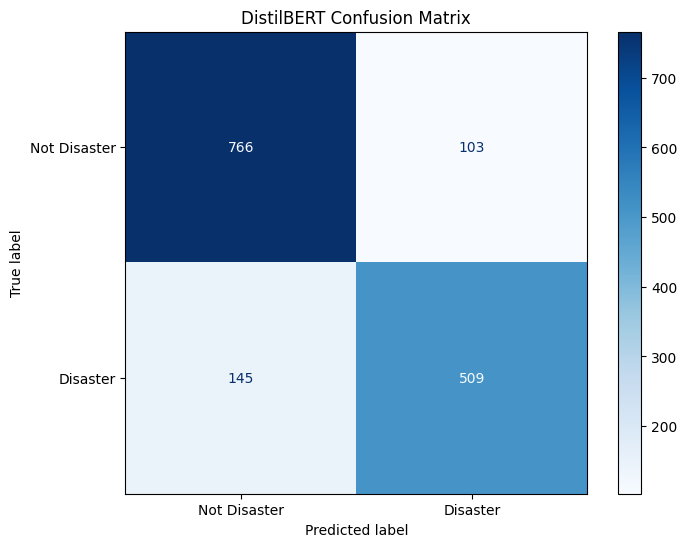

In [28]:
# 1. Get predictions for the validation set
val_output = trainer.predict(tokenized_val)
y_true = val_output.label_ids
y_pred = np.argmax(val_output.predictions, axis=-1)

# 2. Build the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot it
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Disaster', 'Disaster'])
disp.plot(cmap='Blues', ax=ax)
plt.title('DistilBERT Confusion Matrix')
plt.show()

In [29]:
pd.set_option('display.max_colwidth', None)
results_df = pd.DataFrame({
    'text': X_val,
    'true': y_true,
    'pred': y_pred
})

# Filter for the ones the model got WRONG
mistakes = results_df[results_df['true'] != results_df['pred']]

# 2. Filter for those 142 "Missed Disasters" (False Negatives)
missed_disasters = mistakes[(mistakes['true'] == 1) & (mistakes['pred'] == 0)]

# 3. Look at 10 random examples to find patterns
print("--- REAL DISASTERS THE MODEL MISSED ---")
print(missed_disasters['text'].sample(10))

--- REAL DISASTERS THE MODEL MISSED ---
1737                      collided  Cyclist who collided with runner on Roanoke greenway wins $300000 civil verdict - Roanoke Times: Cyclist who c  url
6977                                                                                     twister  It's alil twister at Tha end to! I was like oh nah ??
6119            sinking  That horrible sinking feeling when youve been at home on your phone for a while and you realise its been on 3G this whole time
1999    damage Unknown user yeah but being fast and doing extremely high damage is what its all about if you want fast then im gonna have to get u the-
4414                                    hijacking  #hot  Funtenna: hijacking computers to send data as sound waves [Black Hat 2015] url #prebreak #best
2478         desolate  Thanks a lot roadworks men cos a tube strike wasn't disruptive enough so having to walk the desolate route from Tottenham to  ..
680                        blazing Pig Symbol, A

## Submit the result

In [30]:
test_df = pd.read_csv("/kaggle/input/competitions/nlp-getting-started/test.csv")

test_df['text_combined'] = test_df['keyword'].fillna('') + " " + \
                             test_df['location'].fillna('') + " " + \
                             test_df['text']
test_df['text_cleaned'] = test_df['text_combined'].apply(light_clean)
 
test_ds = Dataset.from_pandas(pd.DataFrame({'text': test_df['text_cleaned'] }))
tokenized_test = test_ds.map(tokenize_function, batched=True)

raw_preds = trainer.predict(tokenized_test)
final_predictions = np.argmax(raw_preds.predictions, axis=-1)

submission = pd.DataFrame({
    "id": test_df["id"],
    "target": final_predictions
})
submission.to_csv("submission.csv", index=False)

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]